In [63]:
from shapely import geometry
from pystac_client import Client
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import xarray as xr
from distributed import LocalCluster

Setup


In [64]:
# Create local processing cluster
cluster = LocalCluster()
client = cluster.get_client()

harz_boundaries = gpd.read_file("../resources/Nationalpark_Harz_boundaries.geojson")
#bbox = harz_boundaries.geometry.values[0].bounds
bbox = [10.633501, 51.611195, 10.787234, 51.698098]

bbox_polygon = geometry.box(*bbox)
polygon = gpd.GeoDataFrame(index=[0], crs="epsg:4326", geometry=[bbox_polygon])

epsg = 32632  # Sentinel-2 data CRS known a priori
bbox_reproj = polygon.to_crs("epsg:" + str(epsg)).geometry.values[0].bounds


catalog = Client.open("https://stac.core.eopf.eodc.eu")

D:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 64591 instead
  warnings.warn(
C:\Users\janph\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.29s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


In [65]:
def get_item_for_year(year):
    results = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=[f"{year}-01-01", f"{year}-12-31"],
        query={"eo:cloud_cover": {"lt": 30}},  # optional filter
    )
    items = results.item_collection()
    if not items:
        return None

    # pick least cloudy item
    return min(items, key=lambda x: x.properties.get("eo:cloud_cover", 999))

In [66]:

years = range(2019, 2026)

items = [
    item for year in years
    if (item := get_item_for_year(year)) is not None
]
sr_datasets = []

for item in items:
    # Open SR_20m asset for this item
    ds = xr.open_dataset(item.assets["SR_10m"].href, engine="eopf-zarr", chunks={}, decode_timedelta=True)

    # Expand a time dimension using the item's timestamp
    ds = ds.expand_dims(time=pd.to_datetime([item.datetime]).tz_localize(None))

    sr_datasets.append(ds)

# Combine all items into one Dataset along time
r10m = xr.concat(sr_datasets, dim="time", join="outer")
r10m

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 6, y: 10980, x: 10980)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225
  * x            (x) int64 88kB 600005 600015 600025 ... 709775 709785 709795
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>

In [67]:
import xarray as xr
import zarr
import dask.array as da
import pandas as pd

items = [
    item for year in years
    if (item := get_item_for_year(year)) is not None
]
sr_datasets = []


for item in items:
    # ------------------------------------------------------------------
    # 1. Open SR_20m
    # ------------------------------------------------------------------
    ds = xr.open_dataset(
        item.assets["SR_20m"].href,
        engine="eopf-zarr",
        chunks={}
    )

    # ------------------------------------------------------------------
    # 2. Open SCL_20m as a Dask-backed DataArray
    # ------------------------------------------------------------------
    scl_z = zarr.open(item.assets["SCL_20m"].href, mode="r")
    scl_da = xr.DataArray(
        da.from_array(scl_z, chunks=scl_z.chunks),
        dims=("y", "x"),
        name="scl"
    )

    # ------------------------------------------------------------------
    # 3. Add SCL as a new variable to the dataset
    # ------------------------------------------------------------------
    ds = ds.assign(scl=scl_da)

    # ------------------------------------------------------------------
    # 4. Add time dimension consistent with SR dataset
    # ------------------------------------------------------------------
    ds = ds.expand_dims(time=[pd.to_datetime(item.datetime).tz_localize(None)])

    sr_datasets.append(ds)

# ----------------------------------------------------------------------
# 5. Combine all datasets into a single time stack
# ----------------------------------------------------------------------
r20m_mask_l2a_classification = xr.concat(sr_datasets, dim="time", join="outer")
r20m_mask_l2a_classification

<xarray.Dataset> Size: 15GB
Dimensions:      (time: 6, y: 5490, x: 5490)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) int64 44kB 5800010 5799990 5799970 ... 5690250 5690230
  * x            (x) int64 44kB 600010 600030 600050 ... 709750 709770 709790
    spatial_ref  int64 8B 0
Data variables:
    b01          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b02          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b05          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b06          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b07          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b11          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b12          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b8a          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    scl          (time, y, x) uint8 181MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [68]:
factor = 10
r100m = r10m.coarsen(x=factor, y=factor, boundary="trim").mean()
r100m.sel()

<xarray.Dataset> Size: 231MB
Dimensions:      (time: 6, y: 1098, x: 1098)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 58MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b03          (time, y, x) float64 58MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b04          (time, y, x) float64 58MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b08          (time, y, x) float64 58MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>

In [69]:

target_chunks = {dim: ch[0] for dim, ch in zip(r100m["b02"].dims, r100m["b02"].chunks)}

# Interpolate and rechunk the SCL layer
scl_100m = (
    r20m_mask_l2a_classification.scl
    .chunk({"x": -1, "y": -1})  # merge chunks along x and y for interpolation
    .interp(x=r100m["x"], y=r100m["y"], method="nearest")
    .chunk(target_chunks)        # apply target chunks from r100m
)
# TODO: Why not coarse this aswell? Is it because we have to interpolate anyhow, because of resolution?
scl_100m

<xarray.DataArray 'scl' (time: 6, y: 1098, x: 1098)> Size: 58MB
dask.array<rechunk-merge, shape=(6, 1098, 1098), dtype=float64, chunksize=(1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int64 8B 0

In [70]:
def validate_scl(scl):
    invalid = [0, 1, 3, 7, 8, 9, 10]  # NO_DATA, SATURATED, CLOUD, etc.
    return ~scl.isin(invalid)


valid_mask = validate_scl(scl_100m)
valid_r100m = r100m.where(valid_mask) # Applying the mask
valid_mask

<xarray.DataArray 'scl' (time: 6, y: 1098, x: 1098)> Size: 7MB
dask.array<invert, shape=(6, 1098, 1098), dtype=bool, chunksize=(1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int64 8B 0

Problem: Maybe the data we are using is obstructed by clouds e.g. and is being thrown out of the Mask?


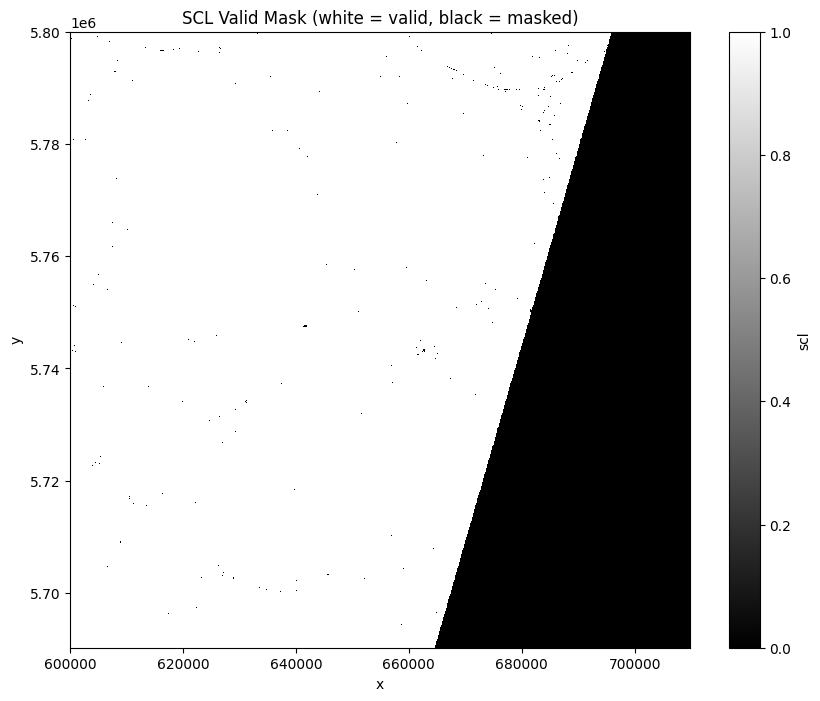

In [71]:
import matplotlib.pyplot as plt

# If it has a time dimension, pick the first timestep
mask_slice = valid_mask.isel(time=0) if "time" in valid_mask.dims else valid_mask

plt.figure(figsize=(10, 8))
mask_slice.plot(cmap="gray")  # True will be white, False black
plt.title("SCL Valid Mask (white = valid, black = masked)")
plt.show()


In [72]:
mask_ratio = (~valid_mask).sum() / valid_mask.size
print(f"Fraction of pixels masked: {mask_ratio.values:.2%}")

Fraction of pixels masked: 20.73%


Result: Too little pixels removed for it to mess up the data that much.


In [73]:
from datetime import datetime

# Stack bands and NDVI, scale to match Sentinel Hub
# Not sure if we need to concat in this way? can keep it as data arrays in the dataset may be here??
scale = valid_r100m["b04"].attrs["_eopf_attrs"]["scale_factor"]
offset = valid_r100m["b08"].attrs["_eopf_attrs"]["add_offset"]
reflectances_r100m = (valid_r100m * scale) + offset

b08 = reflectances_r100m["b08"]
b04 = reflectances_r100m["b04"]
ndvi = (b08 - b04) / (b08 + b04)  # Per-pixel NDVI


reflectances_r100m["ndvi"] = ndvi

x_slice = slice(bbox_reproj[0], bbox_reproj[2])  # ~100 pixels
y_slice = slice(bbox_reproj[3], bbox_reproj[1])  # ~100 pixels

cloudless_bands_ndvi = reflectances_r100m.sel(
    time=datetime(2018, 6, 4), method="nearest"
)

region = cloudless_bands_ndvi.sel(x=x_slice, y=y_slice).chunk(
    {"y": "auto", "x": "auto"}
)

rgb = region[["b04", "b03", "b02"]].to_dataarray(dim="bands")
#rgb = (rgb - 0.02) / (0.35 - 0.02)  # Stretch 0.02-0.35 to 0-1
#rgb = rgb.clip(0, 1).compute()

ndvi = region["ndvi"].compute()

yearly_ds = (
    reflectances_r100m.sel(x=x_slice, y=y_slice)
    .groupby("time.year")
    .mean(dim="time", skipna=True)
)
yearly_ds

<xarray.Dataset> Size: 3MB
Dimensions:      (year: 6, y: 100, x: 109)
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    b03          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    b04          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    b08          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    ndvi         (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>

In [74]:
yearly_ds.ndvi.attrs

{'_eopf_attrs': {'add_offset': -0.1,
  'coordinates': ['x', 'y'],
  'dimensions': ['y', 'x'],
  'fill_value': 0,
  'scale_factor': 0.0001,
  'units': 'digital_counts'},
 'dtype': '<u2',
 'fill_value': 0,
 'proj:bbox': [600000.0, 5690220.0, 709800.0, 5800020.0],
 'proj:epsg': 32632,
 'proj:shape': [10980, 10980],
 'proj:transform': [10.0, 0.0, 600000.0, 0.0, -10.0, 5800020.0, 0.0, 0.0, 1.0],
 'proj:wkt2': 'PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","326

In [75]:
ndvi.min().item(), ndvi.max().item(), ndvi.mean().item()

(-0.0002455926161641369, -2.9879810177556407e-05, -0.00012251697655563465)

In [76]:
ndvi.data

array([[-8.34588338e-05, -8.20178822e-05, -8.40732514e-05, ...,
        -8.89293842e-05, -1.38902790e-04, -2.11345026e-04],
       [-7.39279670e-05, -8.45935388e-05, -7.69959557e-05, ...,
        -1.57967383e-04, -1.41899095e-04, -2.04551946e-04],
       [-7.40139128e-05, -8.69959478e-05, -9.06174722e-05, ...,
        -1.36524660e-04, -1.12234850e-04, -1.33644798e-04],
       ...,
       [-1.77964133e-04, -1.80239809e-04, -1.81004942e-04, ...,
        -1.49051555e-04, -1.50716801e-04, -1.32994337e-04],
       [-1.55861507e-04, -1.71772672e-04, -1.74435586e-04, ...,
        -1.44076848e-04, -1.60493529e-04, -1.38245882e-04],
       [-1.50495288e-04, -1.65970620e-04, -1.65066646e-04, ...,
        -1.47379184e-04, -1.38249193e-04, -1.47428496e-04]],
      shape=(100, 109))

In [77]:
def plot_rgb_ndvi(dset, year, x_slice, y_slice):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Date - " + str(year) + "\n")

    # First subplot
    rgb = dset[["b04", "b03", "b02"]].to_dataarray(dim="bands")
    rgb = (rgb - 0.02) / (0.35 - 0.02)  # Stretch 0.02-0.35 to 0-1
    rgb = rgb.clip(0, 1)  # Clip to valid range
    rgb.plot.imshow(
        ax=ax1,
        rgb="bands",
        extent=(x_slice.start, x_slice.stop, y_slice.start, y_slice.stop),
    )
    ax1.set_title("RGB (Enhanced)")

    # Second plot
    ndvi_plot = dset["ndvi"].plot(
        ax=ax2, cmap="Greens", vmin=-1, vmax=1, add_colorbar=False
    )
    ax2.set_title("NDVI")

    # Add color bar on the right
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    fig.colorbar(ndvi_plot, cax=cbar_ax)

In [78]:
year = 2020
region = yearly_ds.sel(year=year)

region

<xarray.Dataset> Size: 438kB
Dimensions:      (y: 100, x: 109)
Coordinates:
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
    spatial_ref  int64 8B 0
    year         int64 8B 2020
Data variables:
    b02          (y, x) float64 87kB dask.array<chunksize=(22, 54), meta=np.ndarray>
    b03          (y, x) float64 87kB dask.array<chunksize=(22, 54), meta=np.ndarray>
    b04          (y, x) float64 87kB dask.array<chunksize=(22, 54), meta=np.ndarray>
    b08          (y, x) float64 87kB dask.array<chunksize=(22, 54), meta=np.ndarray>
    ndvi         (y, x) float64 87kB dask.array<chunksize=(22, 54), meta=np.ndarray>

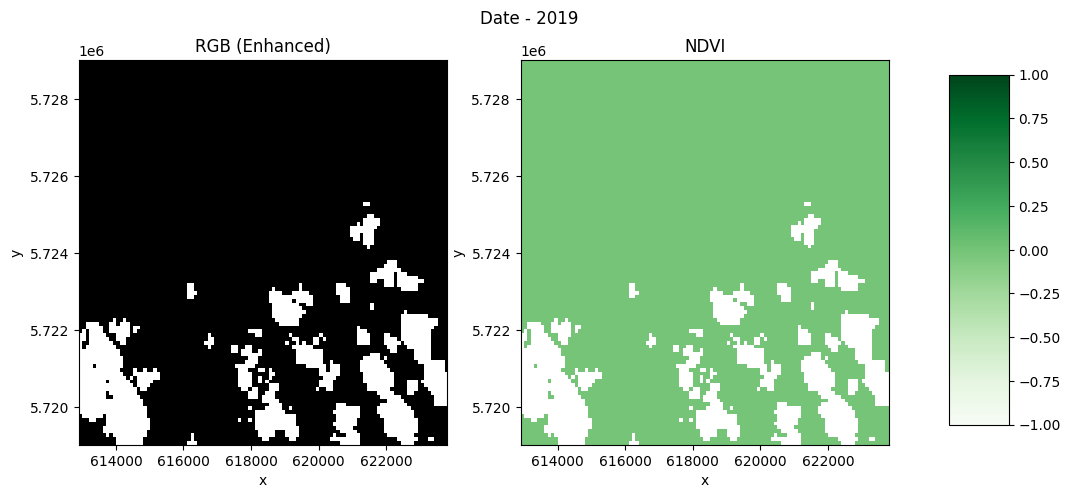

In [79]:
plot_rgb_ndvi(region, 2019, x_slice, y_slice)

In [80]:
yearly_ds

<xarray.Dataset> Size: 3MB
Dimensions:      (year: 6, y: 100, x: 109)
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    b03          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    b04          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    b08          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    ndvi         (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>

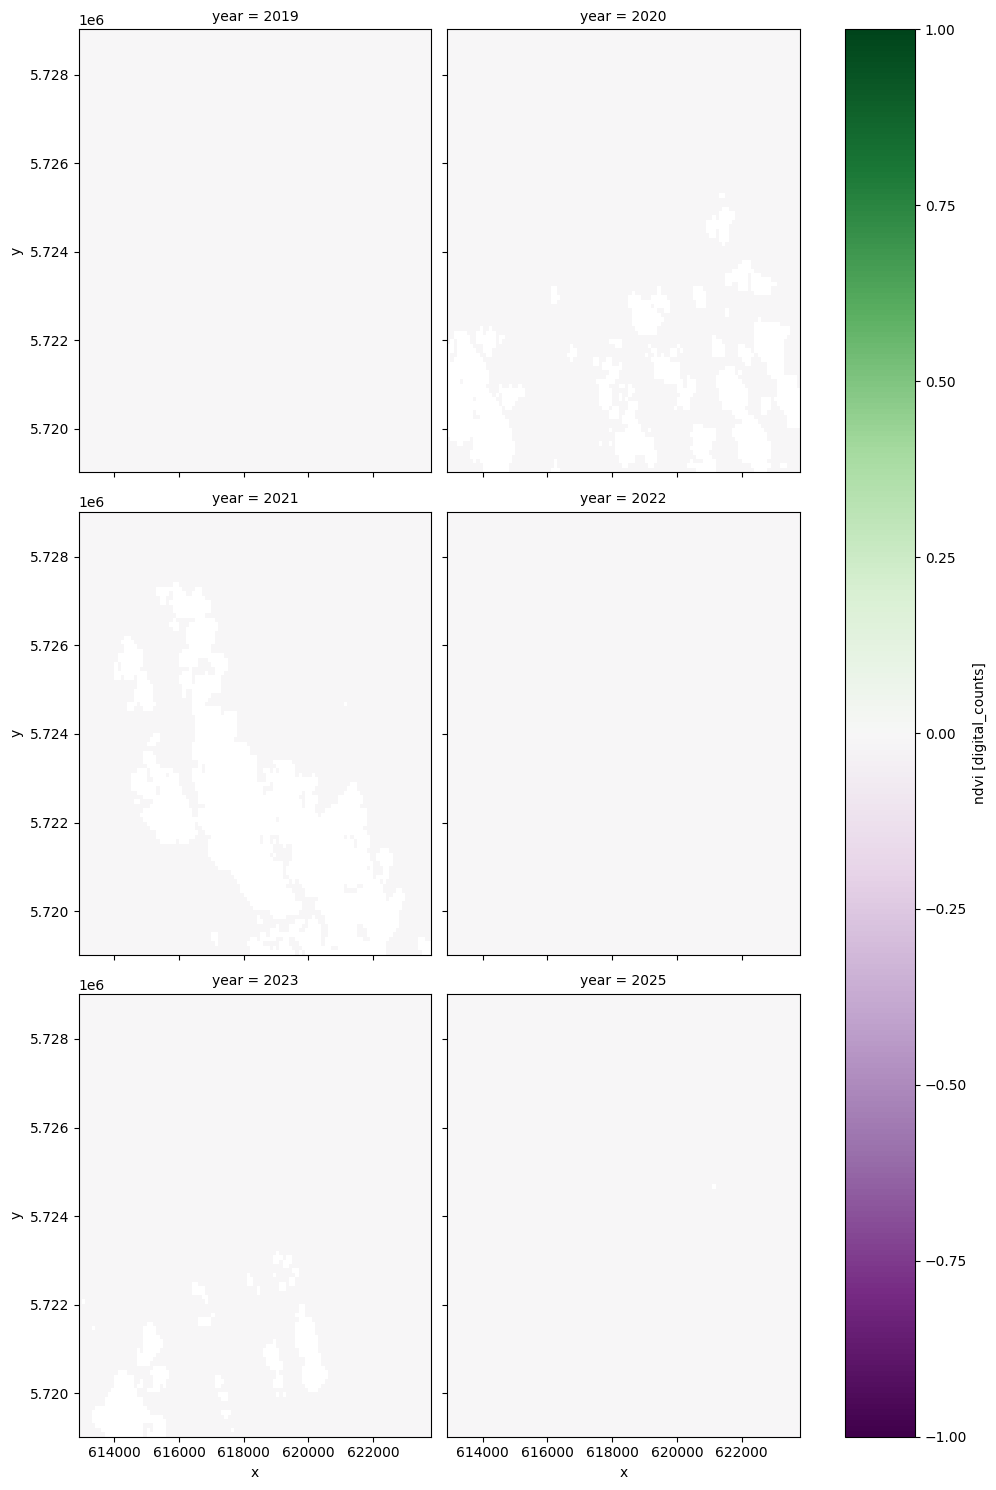

In [81]:
ndvi_yearly = yearly_ds["ndvi"].sel(x=x_slice, y=y_slice).sel(
    year=slice(2018, 2025)
)

ndvi_yearly.plot(
    cmap="PRGn", x="x", y="y", col="year", col_wrap=2, vmin=-1, vmax=1, figsize=(10, 15)
)

In [82]:
yearly_ds.ndvi.values

array([[[-8.34588338e-05, -8.20178822e-05, -8.40732514e-05, ...,
         -8.89293842e-05, -1.38902790e-04, -2.11345026e-04],
        [-7.39279670e-05, -8.45935388e-05, -7.69959557e-05, ...,
         -1.57967383e-04, -1.41899095e-04, -2.04551946e-04],
        [-7.40139128e-05, -8.69959478e-05, -9.06174722e-05, ...,
         -1.36524660e-04, -1.12234850e-04, -1.33644798e-04],
        ...,
        [-1.77964133e-04, -1.80239809e-04, -1.81004942e-04, ...,
         -1.49051555e-04, -1.50716801e-04, -1.32994337e-04],
        [-1.55861507e-04, -1.71772672e-04, -1.74435586e-04, ...,
         -1.44076848e-04, -1.60493529e-04, -1.38245882e-04],
        [-1.50495288e-04, -1.65970620e-04, -1.65066646e-04, ...,
         -1.47379184e-04, -1.38249193e-04, -1.47428496e-04]],

       [[-6.45893480e-05, -6.39336881e-05, -6.59368674e-05, ...,
         -8.18913281e-05, -8.81704084e-05, -1.62304230e-04],
        [-6.22994811e-05, -6.48783124e-05, -5.94638966e-05, ...,
         -1.24093769e-04, -1.01991947e

In [83]:
import numpy as np
yearly_ds.ndvi.load()
yearly_ds["FOREST"] = yearly_ds.ndvi > 0.7

def to_km2(dataarray, resolution):
    # Calculate forest area
    return dataarray * np.prod(list(resolution)) / 1e6


resolution = (100, 100)
forest_pixels = yearly_ds.sel(x=x_slice, y=y_slice).FOREST.sum(["x", "y"])
forest_area_km2 = to_km2(forest_pixels, resolution)
forest_area_km2


<xarray.DataArray 'FOREST' (year: 6)> Size: 48B
array([0., 0., 0., 0., 0., 0.])
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
    spatial_ref  int64 8B 0
Attributes: (12)

In [84]:
yearly_ds["FOREST"]

forest_area_km2.load()


<xarray.DataArray 'FOREST' (year: 6)> Size: 48B
array([0., 0., 0., 0., 0., 0.])
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
    spatial_ref  int64 8B 0
Attributes: (12)

In [85]:
yearly_ds.ndvi

<xarray.DataArray 'ndvi' (year: 6, y: 100, x: 109)> Size: 523kB
array([[[-8.34588338e-05, -8.20178822e-05, -8.40732514e-05, ...,
         -8.89293842e-05, -1.38902790e-04, -2.11345026e-04],
        [-7.39279670e-05, -8.45935388e-05, -7.69959557e-05, ...,
         -1.57967383e-04, -1.41899095e-04, -2.04551946e-04],
        [-7.40139128e-05, -8.69959478e-05, -9.06174722e-05, ...,
         -1.36524660e-04, -1.12234850e-04, -1.33644798e-04],
        ...,
        [-1.77964133e-04, -1.80239809e-04, -1.81004942e-04, ...,
         -1.49051555e-04, -1.50716801e-04, -1.32994337e-04],
        [-1.55861507e-04, -1.71772672e-04, -1.74435586e-04, ...,
         -1.44076848e-04, -1.60493529e-04, -1.38245882e-04],
        [-1.50495288e-04, -1.65970620e-04, -1.65066646e-04, ...,
         -1.47379184e-04, -1.38249193e-04, -1.47428496e-04]],

       [[-6.45893480e-05, -6.39336881e-05, -6.59368674e-05, ...,
         -8.18913281e-05, -8.81704084e-05, -1.62304230e-04],
        [-6.22994811e-05, -6.48783124e-05, -5.94638966e-05, ...,
         -1.24093769e-04, -1.01991947e-04, -1.73962995e-04],
        [-5.79561783e-05, -6.89825350e-05, -7.09651411e-05, ...,
         -1.12926644e-04, -8.60804743e-05, -1.51619953e-04],
...
         -1.57187120e-04, -1.68403691e-04, -1.71109200e-04],
        [-1.88672124e-04, -1.99192313e-04, -2.19392993e-04, ...,
         -1.61116800e-04, -1.74325321e-04, -1.63496242e-04],
        [-1.91898221e-04, -2.12569768e-04, -2.14459874e-04, ...,
         -1.66855387e-04, -1.52424806e-04, -1.77636343e-04]],

       [[-1.10352079e-04, -1.23737805e-04, -1.39662960e-04, ...,
         -1.29829132e-04, -1.52884278e-04, -1.67122072e-04],
        [-1.30074829e-04, -1.43802304e-04, -1.22298441e-04, ...,
         -1.53627561e-04, -1.59022814e-04, -1.73836457e-04],
        [-1.06726323e-04, -1.52308720e-04, -1.44216265e-04, ...,
         -1.53469843e-04, -1.78950736e-04, -1.94462963e-04],
        ...,
        [-1.46066691e-04, -1.84131854e-04, -1.96317157e-04, ...,
         -1.45220386e-04, -1.47283926e-04, -1.44649666e-04],
        [-1.66561120e-04, -1.73020904e-04, -1.76855368e-04, ...,
         -1.40759192e-04, -1.60422814e-04, -1.56639053e-04],
        [-1.59923079e-04, -1.64950267e-04, -1.69057270e-04, ...,
         -1.43454888e-04, -1.46741499e-04, -1.64687174e-04]]],
      shape=(6, 100, 109))
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
    spatial_ref  int64 8B 0
Attributes: (12)

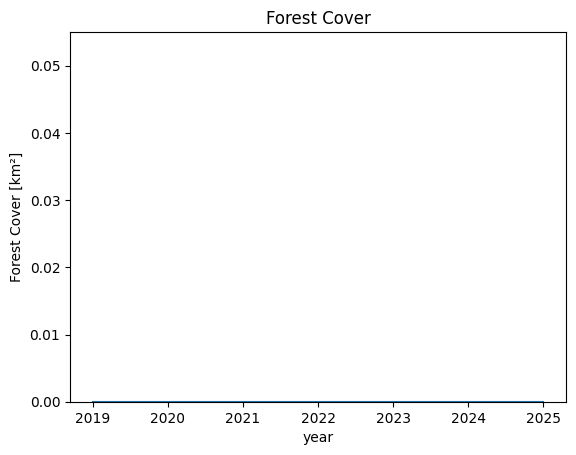

In [86]:

forest_area_km2.plot()

plt.title("Forest Cover")
plt.ylabel("Forest Cover [km²]")
plt.ylim(0);

In [87]:
forest_area_km2

<xarray.DataArray 'FOREST' (year: 6)> Size: 48B
array([0., 0., 0., 0., 0., 0.])
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
    spatial_ref  int64 8B 0
Attributes: (12)